# Setup

In [1]:
### Imports
### System
import sys, os, shutil
import glob

### I/O
import h5py
import tables_io

### Operations
import numpy as np

### RAIL
from rail.core.data import DataStore, PqHandle, ModelHandle
from rail.core.stage import RailStage

sys.path.insert(0, "/global/homes/s/sajkov/rail_umap/src/degrading")
from MultiSurveyErrorModel import MultiSurveyErrorModel

sys.path.insert(0, "/global/homes/s/sajkov/rail_umap/src/estimation")
from UMAPEstimator import UMAPEstimator

### Set the date, start the timer
import time
date = time.strftime('%d%b%y', time.localtime())

In [2]:
### Set up LePhare
path_to_lp_config_file    = "/pscratch/sd/s/sajkov/analysis_pipeline/lephare/lsst.para"
os.environ["LEPHAREDIR"]  = f"{os.path.dirname(path_to_lp_config_file)}/data"
os.environ["LEPHAREWORK"] = f"{os.path.dirname(path_to_lp_config_file)}/work"

from rail.estimation.algos.lephare import LephareInformer, LephareEstimator
import lephare as lp
lephare_config = lp.read_config("/pscratch/sd/s/sajkov/analysis_pipeline/lephare/lsst.para")
lp.data_retrieval.get_auxiliary_data(keymap = lephare_config)

path_to_filters = "/pscratch/sd/s/sajkov/analysis_pipeline/filters"
os.makedirs(f"{os.environ["LEPHAREDIR"]}/filt/pipeline", exist_ok = True)
for f in glob.glob(f"{path_to_filters}/*.dat"):
    if f.endswith("F146.dat"):
        continue
    shutil.copy(f, f"{os.environ["LEPHAREDIR"]}/filt/pipeline/")

FILTER_LIST = ",".join([f"pipeline/{os.path.basename(f)}" for f in glob.glob(f"{os.environ["LEPHAREDIR"]}/filt/pipeline/*.dat")])
lephare_config["FILTER_LIST"].value = FILTER_LIST
lephare_config["FILTER_FILE"].value = "filter_pipeline"

os.makedirs(f"{os.environ["LEPHAREDIR"]}/output", exist_ok = True)
lephare_config["PARA_OUT"].value = f"{os.environ["LEPHAREDIR"]}/output/output_{date}.para"

lp.data_retrieval.get_auxiliary_data(keymap=lephare_config)

User defined LEPHAREDIR is set. Code runs depend on all required
auxiliary data being present at /pscratch/sd/s/sajkov/analysis_pipeline/lephare/data.
User defined LEPHAREWORK is set. All intermediate files will be written to:
 /pscratch/sd/s/sajkov/analysis_pipeline/lephare/work
Number of keywords read in the config file: 86
Registry file downloaded and saved as data_registry.txt.
Checking/downloading 421 files...
421 completed.
All files downloaded successfully and are non-empty.
Registry file downloaded and saved as data_registry.txt.
Checking/downloading 444 files...
Future completed with an exception: File 'filt/pipeline/Roman_F158.dat' is not in the registry.
Future completed with an exception: File 'filt/pipeline/LSST_i.dat' is not in the registry.
Future completed with an exception: File 'filt/pipeline/LSST_y.dat' is not in the registry.
Future completed with an exception: File 'filt/pipeline/HSC_MB_05.dat' is not in the registry.
Future completed with an exception: File 'filt/

In [3]:
### Initialize random state
seed = 42
rng = np.random.default_rng(seed = seed)

In [4]:
### Specify outputs directory
outputs_directory = f"/pscratch/sd/s/sajkov/analysis_pipeline/runs/{date}"
if not os.path.exists(outputs_directory):
    os.makedirs(outputs_directory)

# Stage 1: Create datasets


In [5]:
### Specify path to noiseless catalog and redshifts
noiseless_catalog_filepath = "/pscratch/sd/s/sajkov/data/integrated_catalog_23apr26.pq"
redshifts_filepath = "/pscratch/sd/s/sajkov/data/mock_catalog_Ch1_26.h5"

In [6]:
DATASET_popCosmos_full   = tables_io.read(noiseless_catalog_filepath)
REDSHIFTS_popCosmos_full = h5py.File(redshifts_filepath)['sps_parameters'][:, -1]

column_list None


In [7]:
### Number of pop-cosmos sources to use in analysis
data_cut = 100_000

### Fraction of deep field versus WFD photometry
deep_field_frac = 0.2

### Randomize full dataset indices, take `deep_field_frac` to be the deep field, let the rest be WFD
RANDIDX_popCosmos_full = rng.choice(np.arange(len(DATASET_popCosmos_full)), len(DATASET_popCosmos_full), replace = False)
RANDIDX_popCosmos_cut  = RANDIDX_popCosmos_full[:int(data_cut * (1 + deep_field_frac))]

deep_field_cut = int(deep_field_frac * data_cut)
IDX_popCosmos_DeepField             = RANDIDX_popCosmos_cut[:deep_field_cut]
IDX_popCosmos_DeepField_lpReference = RANDIDX_popCosmos_cut[deep_field_cut:2*deep_field_cut]
IDX_popCosmos_WideFastDeep          = RANDIDX_popCosmos_cut[2*deep_field_cut:]

In [8]:
### 5-sigma limiting depths ------------------
### LSST: median values for COSMOS deep field from https://usdf-maf.slac.stanford.edu/summaryStats?runId=5#Basics_Coadd%20M5
### Roman from https://github.com/jfcrenshaw/photerr/blob/a014b39729ddde3daf80be2dbe82f5a7f958882c/photerr/roman.py#L120-L126
### HSC Niji (60 min exposure) from https://sites.google.com/view/hsc-mb-survey3/filter-specification?authuser=0 
###
### Acessed June 3, 2026
### --------------------------------------------

M5_DEPTHS_DeepField = {'LSST_u'    : 27.74,
                      'LSST_g'    : 28.69,
                      'LSST_r'    : 28.88,
                      'LSST_i'    : 28.96,
                      'LSST_z'    : 28.26,
                      'LSST_y'    : 26.63,
                      'Roman_F062': 27.7,
                      'Roman_F087': 27.7,
                      'Roman_F106': 27.6,
                      'Roman_F129': 27.5,
                      'Roman_F158': 27.0,
                      'Roman_F184': 25.9,
                      'Roman_F213': 28.3,
                      'HSC_MB_00' : 26.41,
                      'HSC_MB_01' : 26.51,
                      'HSC_MB_02' : 26.45,
                      'HSC_MB_03' : 26.69,
                      'HSC_MB_04' : 26.93,
                      'HSC_MB_05' : 26.62,
                      'HSC_MB_06' : 26.26,
                      'HSC_MB_07' : 26.02,
                      'HSC_MB_08' : 26.07,
                      'HSC_MB_09' : 26.00,
                      'HSC_MB_10' : 26.06,
                      'HSC_MB_11' : 25.52,
                      'HSC_MB_12' : 25.58,
                      'HSC_MB_13' : 25.43,
                      'HSC_MB_14' : 25.15,
                      'HSC_MB_15' : 24.79}


### 5-sigma limiting depths for WideFastDeep from https://usdf-maf.slac.stanford.edu/summaryStats?runId=5#Basics_Coadd%20M5
### Column `DD:WFD CoaddM5`
M5_DEPTHS_WideFastDeep = {'LSST_u'    : 25.61,
                          'LSST_g'    : 26.90,
                          'LSST_r'    : 26.87,
                          'LSST_i'    : 26.43,
                          'LSST_z'    : 25.73,
                          'LSST_y'    : 24.79}

### Get list of bands
BANDS_DeepField = list(M5_DEPTHS_DeepField.keys())
ERR_BANDS_DeepField = [f"{key}_err" for key in BANDS_DeepField]

BANDS_WideFastDeep = list(M5_DEPTHS_WideFastDeep.keys())
ERR_BANDS_WideFastDeep = [f"{key}_err" for key in BANDS_WideFastDeep]

In [9]:
### Select needed bands and pick out needed sources
PHOTOMETRY_DeepField_noiseless                = DATASET_popCosmos_full[BANDS_DeepField].iloc[IDX_popCosmos_DeepField]
PHOTOMETRY_DeepField_lpReference_noiseless    = DATASET_popCosmos_full[BANDS_DeepField].iloc[IDX_popCosmos_DeepField_lpReference]
PHOTOMETRY_WideFastDeep_noiseless             = DATASET_popCosmos_full[BANDS_WideFastDeep].iloc[IDX_popCosmos_WideFastDeep]

### Same as above, for redshifts
REDSHIFTS_DeepField                = REDSHIFTS_popCosmos_full[IDX_popCosmos_DeepField]
REDSHIFTS_DeepField_lpReference    = REDSHIFTS_popCosmos_full[IDX_popCosmos_DeepField_lpReference]
REDSHIFTS_WideFastDeep             = REDSHIFTS_popCosmos_full[IDX_popCosmos_WideFastDeep]

## Apply noise

In [10]:
### Noising parameters

nYrObs     = 1 # one-year depths
nVisYr     = 1 # one visit/yr (i.e., no co-adds)
gamma      = 0.04
sigLim     = 0 # 
inputType  = 'pogson' # input pogson magnitudes (AB)
outputType = 'asinh'  # output asinh magnitudes

seed = 42

### DP 1.1: Deep, multi-band, medium-band photometry + degraded LSST photometry

In [11]:
noisyPhotometryPath_DeepField = f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_{date}.pq"

getNoisyDeepFieldPhotometry = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry",
    
    inputType  = inputType,
    outputType = outputType,

    noisy_catalog     = noisyPhotometryPath_DeepField,
    
    m5     = M5_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry.set_data("noiseless_catalog", PHOTOMETRY_DeepField_noiseless) 
getNoisyDeepFieldPhotometry.run()
getNoisyDeepFieldPhotometry.get_handle("noisy_catalog").write()
getNoisyDeepFieldPhotometry.finalize()

2026-07-06 10:57:14 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyDeepFieldPhotometry
2026-07-06 10:57:14 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyDeepFieldPhotometry: /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/inprogress_PHOTOMETRY_DeepField_noisy_06Jul26.pq, getNoisyDeepFieldPhotometry


In [12]:
noisyPhotometryPath_DeepField_LePhareReference = f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_lpReference_{date}.pq"

getNoisyDeepFieldPhotometry_lpReference = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry_lpReference",
    
    inputType  = inputType,
    outputType = outputType,

    noisy_catalog     = noisyPhotometryPath_DeepField_LePhareReference,
    
    m5     = M5_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry_lpReference.set_data("noiseless_catalog", PHOTOMETRY_DeepField_lpReference_noiseless) 
getNoisyDeepFieldPhotometry_lpReference.run()
getNoisyDeepFieldPhotometry_lpReference.get_handle("noisy_catalog").write()
getNoisyDeepFieldPhotometry_lpReference.finalize()

2026-07-06 10:57:15 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyDeepFieldPhotometry_lpReference
2026-07-06 10:57:15 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyDeepFieldPhotometry_lpReference: /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/inprogress_PHOTOMETRY_DeepField_noisy_lpReference_06Jul26.pq, getNoisyDeepFieldPhotometry_lpReference


### *(((RETURN TO THIS)))* DP 1.2: same as DP 1.1, but with WideFastDeep 5 sigma depths

In [ ]:
# degradedPhotometryPath_DeepField = f"{outputs_directory}/PHOTOMETRY_DeepField_degraded_{date}.pq"

# degradeDeepFieldPhotometry = MultiSurveyErrorModel.make_stage(
#     name = "degradeDeepFieldPhotometry",
    
#     inputType  = inputType,
#     outputType = outputType,

#     noisy_catalog     = degradedPhotometryPath_DeepField,
    
#     m5     = M5_DEPTHS_WideFastDeep,
#     bands  = BANDS_WideFastDeep,
#     nYrObs = nYrObs,
#     nVisYr = nVisYr,
#     gamma  = gamma,
#     sigLim = sigLim,
    
#     seed = seed
# )

# degradeDeepFieldPhotometry.set_data("noiseless_catalog", PHOTOMETRY_DeepField_noiseless) 
# degradeDeepFieldPhotometry.run()
# degradeDeepFieldPhotometry.get_handle("noisy_catalog").write()
# degradeDeepFieldPhotometry.finalize()

### DP 1.3: LSST photometry with no spec-zs

In [13]:
noisyPhotometryPath_WideFastDeep = f"{outputs_directory}//PHOTOMETRY_WideFastDeep_noisy_{date}.pq"

getNoisyWideFastDeepPhotometry = MultiSurveyErrorModel.make_stage(
    name = "getNoisyWideFastDeepPhotometry",
    
    inputType  = inputType,
    outputType = outputType,

    noisy_catalog     = noisyPhotometryPath_WideFastDeep,
    
    m5     = M5_DEPTHS_WideFastDeep,
    bands  = BANDS_WideFastDeep,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyWideFastDeepPhotometry.set_data("noiseless_catalog", PHOTOMETRY_WideFastDeep_noiseless) 
getNoisyWideFastDeepPhotometry.run()
getNoisyWideFastDeepPhotometry.get_handle("noisy_catalog").write()
getNoisyWideFastDeepPhotometry.finalize()

2026-07-06 10:57:18 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyWideFastDeepPhotometry
2026-07-06 10:57:18 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyWideFastDeepPhotometry: /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/inprogress_PHOTOMETRY_WideFastDeep_noisy_06Jul26.pq, getNoisyWideFastDeepPhotometry


### Check outputs

In [14]:
PHOTOMETRY_DeepField_noisy    = tables_io.read(f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_05Jul26.pq")
PHOTOMETRY_DeepField_lpRefernce_noisy    = tables_io.read(f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_lpReference_05Jul26.pq")
PHOTOMETRY_WideFastDeep_noisy = tables_io.read(f"{outputs_directory}/PHOTOMETRY_WideFastDeep_noisy_05Jul26.pq")

column_list None


RuntimeError: pandaParquet file could not be read in with the following arguments: 
 filepath: '/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/PHOTOMETRY_DeepField_noisy_05Jul26.pq', fmt: 'None', keys: None, allow_missing_keys: False, and **kwargs: {} 
 because of error: 
 [Errno 2] No such file or directory: '/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/PHOTOMETRY_DeepField_noisy_05Jul26.pq'

# Stage 2: etimate photo-zs with LePhare on DP 1.1

In [ ]:
outputModelPath_lePhare = f"{outputs_directory}/model_lephare_{date}.pkl"

inform_lephare = LephareInformer.make_stage(
    
    name           = outputModelPath_lePhare,
    nondetect_val  = np.nan,
    model          = "lephare.pkl",
    hdf5_groupname = "",
    
    bands        = BANDS_DeepField,
    err_bands    = ERR_BANDS_DeepField,
    ref_band     = "LSST_i",
    redshift_col = "redshift",
    
    # Use a sparse redshift grid to speed up the notebook
    zmin   = 0,
    zmax   = 3,
    nzbins = 31,
    
    **{
        "lephare.FILTER_LIST": FILTER_LIST,
        "lephare.FILTER_FILE": "filter_pipeline",
    },
    
    # lephare_config = lephare_config # this is important if you want to modify your default setup with the parameter file
)

TRAININGDATA_LePhare = getNoisyDeepFieldPhotometry_lpReference.get_handle("noisy_catalog").data.copy()
TRAININGDATA_LePhare["redshift"] = REDSHIFTS_DeepField_lpReference

# inform_lephare.inform(TRAININGDATA_LePhare[:100])

2026-07-05 13:10:28 [info     ] Inserting handle into data store.  input: None, inform_Lephare
2026-07-05 13:10:28 [info     ] rail_lephare is setting the Z_STEP config to 0.1,0.0,3.0 based on the informer params.
User defined LEPHAREDIR is set. Code runs depend on all required
auxiliary data being present at /pscratch/sd/s/sajkov/analysis_pipeline/lephare/data.
User defined LEPHAREWORK is set. All intermediate files will be written to:
 /pscratch/sd/s/sajkov/analysis_pipeline/lephare/inform_Lephare
# NAME                        IDENT      Lbda_mean Lbeff(Vega)       FWHM     AB-cor    TG-cor      VEGA M_sun(AB)   CALIB      Lb_eff    Fac_corr
HSC_MB_02.dat                 1             0.4655      0.4651      0.0258   -0.1484   -0.3363  -20.5981    5.0550       0      0.4652      1.0000
HSC_MB_07.dat                 2             0.6116      0.6111      0.0367    0.1305    0.2404  -21.4700    4.6475       0      0.6113      1.0000
HSC_MB_01.dat                 3             0.4398    

In [71]:
savedLePhareModel = ModelHandle("lephare.pkl", path = "/global/homes/s/sajkov/UMAPsWithPhotozs/lephare.pkl")

In [ ]:
estimate_lephare = LephareEstimator.make_stage(
    
    name           = "estimate_Lephare",
    model          = savedLePhareModel, #inform_lephare.get_handle("model"),
    hdf5_groupname = "",

    bands        = BANDS_DeepField,
    err_bands    = ERR_BANDS_DeepField,
    ref_band     = "LSST_i",
    
    nondetect_val = np.nan,
    aliases = dict(input="test_data", output="lephare_estim"),
)

lephare_estimated = estimate_lephare.estimate(getNoisyDeepFieldPhotometry.get_handle("noisy_catalog").data[:100])

2026-07-06 12:10:41 [info     ] Inserting handle into data store.  test_data: None, estimate_Lephare
2026-07-06 12:10:41 [info     ] Inserting handle into data store.  lephare.pkl: <class 'rail.core.data.ModelHandle'> /global/homes/s/sajkov/UMAPsWithPhotozs/lephare.pkl, (w), estimate_Lephare
User defined LEPHAREDIR is set. Code runs depend on all required
auxiliary data being present at /pscratch/sd/s/sajkov/analysis_pipeline/lephare/data.
User defined LEPHAREWORK is set. All intermediate files will be written to:
 /pscratch/sd/s/sajkov/analysis_pipeline/lephare/inform_Lephare
2026-07-06 12:10:41 [info     ] Process 0 running estimator on chunk 0 - 100
Using user columns from input table assuming they are in the standard MEME order.
Processing 100 objects with 29 bands
####################################### 
# PHOTOMETRIC REDSHIFT with OPTIONS   # 
# Config file            : 
# CAT_IN                 : undefined
# CAT_OUT                : zphot.out
# CAT_LINES              : 0 1000000

In [ ]:
lephare_estimated

In [77]:
PHOTOZS_DeepField_lephare = np.reshape(lephare_estimated.read().median(), 100)

In [83]:
SIGMAS_photozs_DeepField_lephare = np.reshape(lephare_estimated.read().std(), 100)

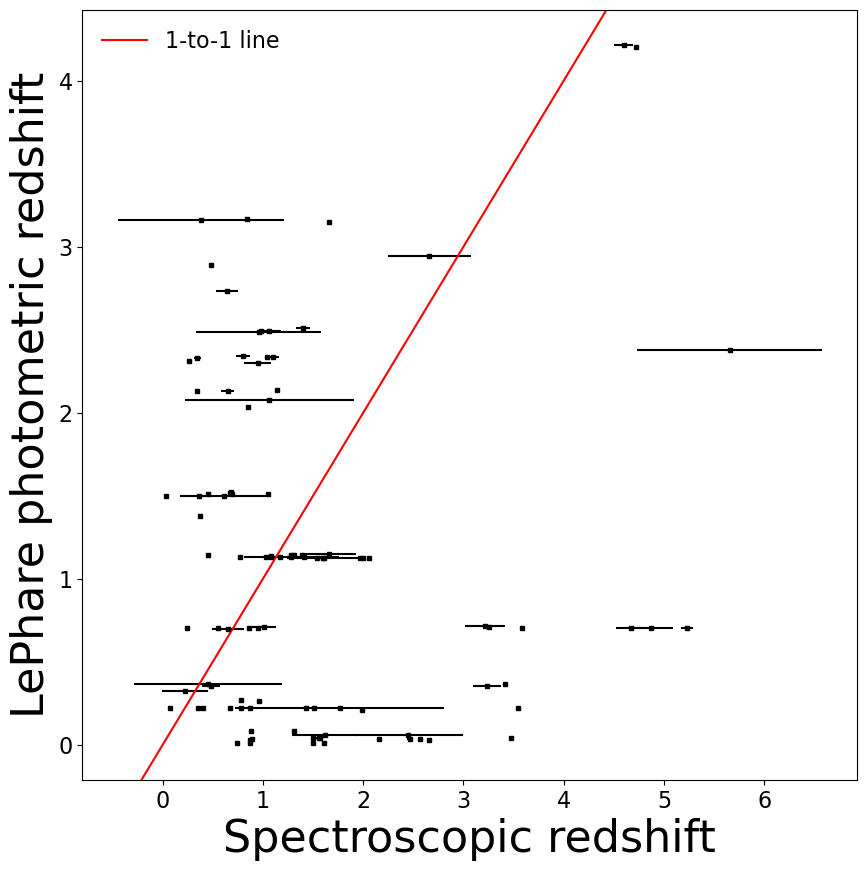

In [108]:
fig = plt.figure(figsize = (10 ,10))
ax = fig.add_subplot()

ax.errorbar(REDSHIFTS_DeepField[:100], PHOTOZS_DeepField_lephare,
            xerr = SIGMAS_photozs_DeepField_lephare, color = "black", linestyle = "none",
           marker = "s", markersize = 3)
ax.axline([0, 0], slope = 1, color = "red", label = "1-to-1 line")
ax.set_xlabel("Spectroscopic redshift", fontsize = 32)
ax.set_ylabel("LePhare photometric redshift", fontsize = 32)

ax.legend(frameon = False, fontsize = 16, loc = "upper left")
ax.tick_params(labelsize = 16)

fig.savefig("firstLePhareOutput.png", dpi = 150, bbox_inches = "tight")

# Stage 3: inform two UMAPs:

In [41]:
### UMAP Parameters
ambient_metric_umap = "manhattan_weighted_linear"
n_neighbors_umap    = 10
min_dist            = 0.05

n_neighbors_knn = 100
metric_p_knn   = 2

precision_gauss_kde = 0.1

### DP 3.0: prepare input data

In [42]:
training_cut = 500
testing_cut = 1000

In [43]:
TRAINING_DATA_UMAP = getNoisyDeepFieldPhotometry.get_handle("noisy_catalog").data

TRAINING_PHOTOMETRY_UMAP = TRAINING_DATA_UMAP[BANDS_WideFastDeep][:training_cut]
TRAINING_PHOTOMERRS_UMAP = TRAINING_DATA_UMAP[ERR_BANDS_WideFastDeep][:training_cut]

TRAINING_REDSHIFTS_UMAP_specZs  = REDSHIFTS_DeepField[:training_cut]
TRAINING_REDSHIFTS_UMAP_photoZs = REDSHIFTS_DeepField[:training_cut] #something like: PHOTOZS_DeepField_lephare = np.reshape(lephare_estimated.read().median(), 100)

ESTIMATION_DATA_UMAP = getNoisyWideFastDeepPhotometry.get_handle("noisy_catalog").data

ESTIMATION_PHOTOMETRY_UMAP = ESTIMATION_DATA_UMAP[BANDS_WideFastDeep][:testing_cut]
ESTIMATION_PHOTOMERRS_UMAP = ESTIMATION_DATA_UMAP[ERR_BANDS_WideFastDeep][:testing_cut]

### DP 3.1: with spec-zs

In [ ]:
outputModelPath_UMAP_wSpecZs = f"{outputs_directory}/model_UMAP_wSpecZs_{date}.pkl"

estimatePhotozsUMAP_wSpecZs = UMAPEstimator.make_stage(
    name = outputModelPath_UMAP_wSpecZs,
    
    ambient_metric_umap = ambient_metric_umap,
    
    n_neighbors_umap = n_neighbors_umap,
    min_dist         = min_dist,
    
    n_neighbors_knn = n_neighbors_knn,
    metric_p_knn    = metric_p_knn,
    
    precision_gauss_kde = precision_gauss_kde,
    
    seed = seed
)

estimatePhotozsUMAP_wSpecZs.set_data("training_photometry", data = TRAINING_PHOTOMETRY_UMAP)
estimatePhotozsUMAP_wSpecZs.set_data("training_phot_error", data = TRAINING_PHOTOMERRS_UMAP)
estimatePhotozsUMAP_wSpecZs.set_data("training_redshift",   data = TRAINING_REDSHIFTS_UMAP_specZs)

estimatePhotozsUMAP_wSpecZs.UMAP_informer()

estimatePhotozsUMAP_wSpecZs.set_data("estimation_photometry", data = ESTIMATION_PHOTOMETRY_UMAP)
estimatePhotozsUMAP_wSpecZs.set_data("estimation_phot_error", data = ESTIMATION_PHOTOMERRS_UMAP)
estimatePhotozsUMAP_wSpecZs.UMAP_estimator()

PHOTOZS_estimated_wSpecZs = estimatePhotozsUMAP_wSpecZs.get_handle("estimated_photoz_medians").data

2026-07-06 11:56:15 [info     ] Inserting handle into data store.  training_photometry: None, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wSpecZs_06Jul26.pkl
2026-07-06 11:56:15 [info     ] Inserting handle into data store.  training_phot_error: None, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wSpecZs_06Jul26.pkl
2026-07-06 11:56:15 [info     ] Inserting handle into data store.  training_redshift: None, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wSpecZs_06Jul26.pkl


/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2026-07-06 11:56:15 [info     ] Inserting handle into data store.  informed_reducer_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wSpecZs_06Jul26.pkl: informed_reducer_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/inprogress_model_UMAP_wSpecZs_06Jul26.pkl.pkl, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wSpecZs_06Jul26.pkl
2026-07-06 11:56:15 [info     ] Inserting handle into data store.  informed_embedding_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wSpecZs_06Jul26.pkl: informed_embedding_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/inprogress_model_UMAP_wSpecZs_06Jul26.pkl.pq, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wSpecZs_06Jul26.pkl
2026-07-06 11:56:15 [info     ] Inserting handle into data store.  informed_kNN_regressor_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wSpecZs_06Jul26.pkl: informed_kNN_regressor_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/inprog

### DP 3.2: with photoz-s

In [51]:
outputModelPath_UMAP_wPhotoZs = f"{outputs_directory}/model_UMAP_wPhotoZs_{date}.pkl"

estimatePhotozsUMAP_wPhotoZs = UMAPEstimator.make_stage(
    name = outputModelPath_UMAP_wPhotoZs,
    
    ambient_metric_umap = ambient_metric_umap,
    
    n_neighbors_umap = n_neighbors_umap,
    min_dist         = min_dist,
    
    n_neighbors_knn = n_neighbors_knn,
    metric_p_knn    = metric_p_knn,
    
    precision_gauss_kde = precision_gauss_kde,
    
    seed = seed
)

estimatePhotozsUMAP_wPhotoZs.set_data("training_photometry", data = TRAINING_PHOTOMETRY_UMAP)
estimatePhotozsUMAP_wPhotoZs.set_data("training_phot_error", data = TRAINING_PHOTOMERRS_UMAP)
estimatePhotozsUMAP_wPhotoZs.set_data("training_redshift",   data = TRAINING_REDSHIFTS_UMAP_photoZs)

estimatePhotozsUMAP_wPhotoZs.UMAP_informer()

estimatePhotozsUMAP_wPhotoZs.set_data("estimation_photometry", data = ESTIMATION_PHOTOMETRY_UMAP)
estimatePhotozsUMAP_wPhotoZs.set_data("estimation_phot_error", data = ESTIMATION_PHOTOMERRS_UMAP)
estimatePhotozsUMAP_wPhotoZs.UMAP_estimator()

PHOTOZS_estimated_wPhotoZs = estimatePhotozsUMAP_wPhotoZs.get_handle("estimated_photoz_medians").data

2026-07-06 11:57:50 [info     ] Inserting handle into data store.  training_photometry: None, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wPhotoZs_06Jul26.pkl
2026-07-06 11:57:50 [info     ] Inserting handle into data store.  training_phot_error: None, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wPhotoZs_06Jul26.pkl
2026-07-06 11:57:50 [info     ] Inserting handle into data store.  training_redshift: None, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wPhotoZs_06Jul26.pkl


/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2026-07-06 11:57:51 [info     ] Inserting handle into data store.  informed_reducer_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wPhotoZs_06Jul26.pkl: informed_reducer_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/inprogress_model_UMAP_wPhotoZs_06Jul26.pkl.pkl, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wPhotoZs_06Jul26.pkl
2026-07-06 11:57:51 [info     ] Inserting handle into data store.  informed_embedding_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wPhotoZs_06Jul26.pkl: informed_embedding_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/inprogress_model_UMAP_wPhotoZs_06Jul26.pkl.pq, /pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wPhotoZs_06Jul26.pkl
2026-07-06 11:57:51 [info     ] Inserting handle into data store.  informed_kNN_regressor_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26/model_UMAP_wPhotoZs_06Jul26.pkl: informed_kNN_regressor_/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26

# Stage 4: compare photo-zs

In [52]:
import matplotlib.pyplot as plt
plt.style.use("/global/homes/s/sajkov/umap_nz_cal.mplstyle")

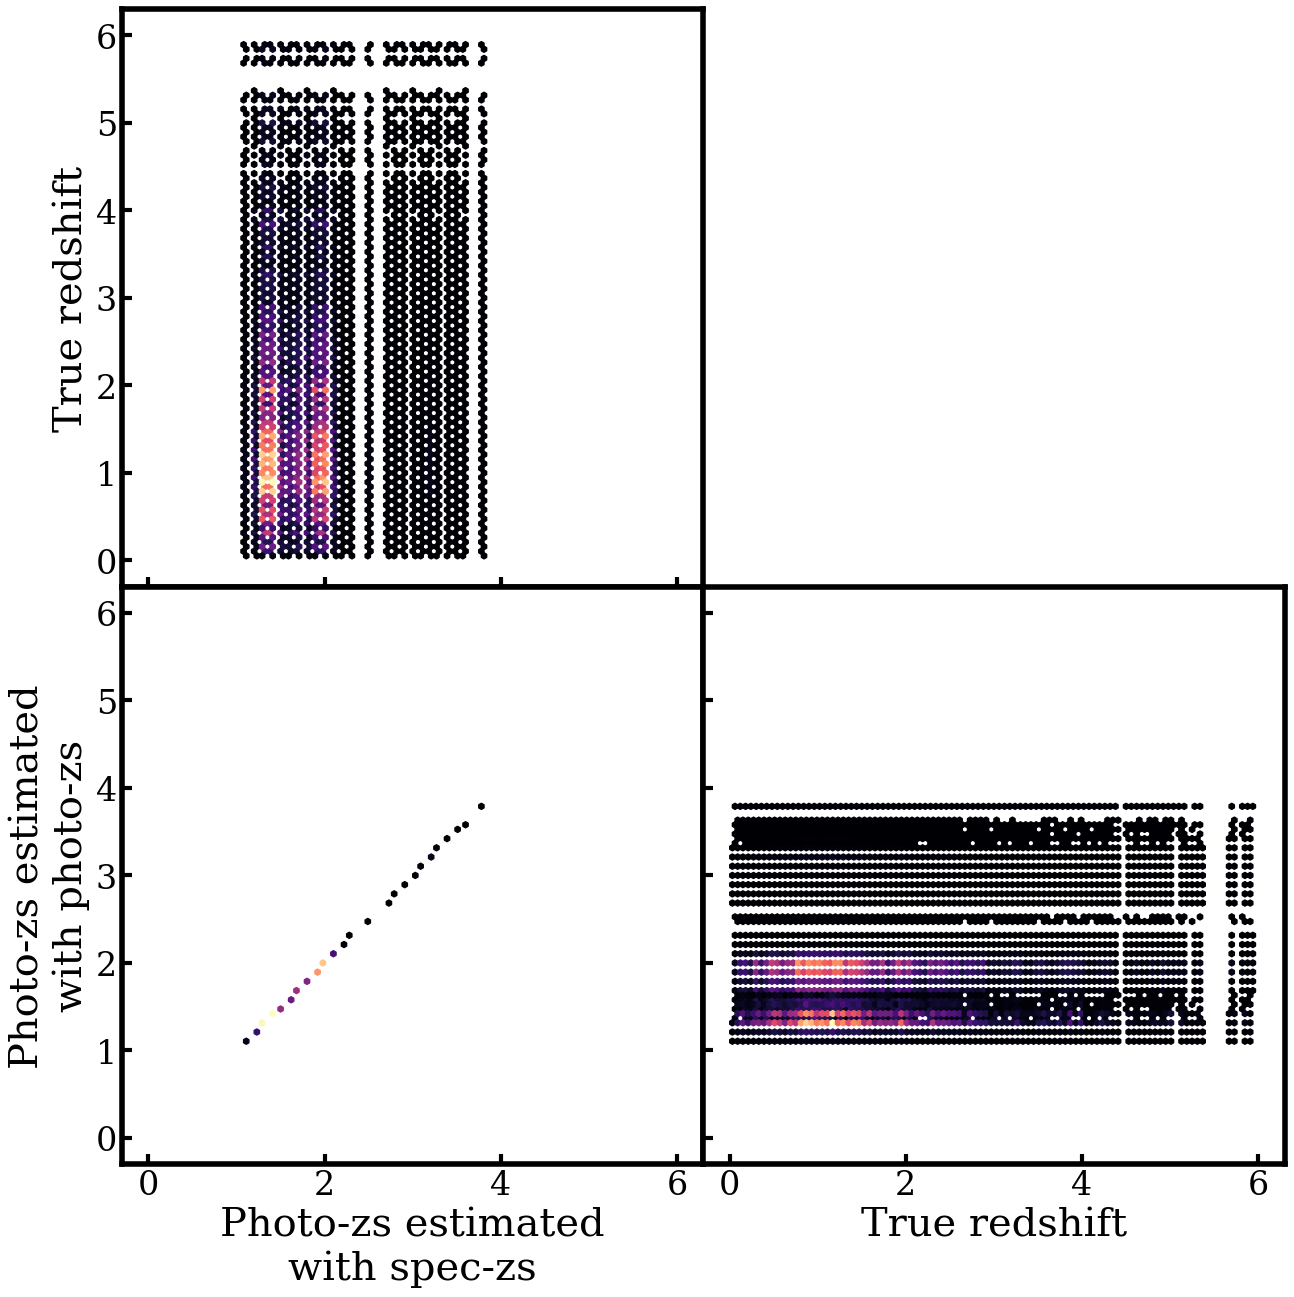

In [69]:
fig = plt.figure(figsize = (15, 15))
axs = fig.subplots(2, 2, sharex = True, sharey = True)

hexbin_props = dict(
    mincnt = 1,
    extent = [0, 6, 0, 6]
)

ax_bl = axs[1, 0]
ax_bl.hexbin(PHOTOZS_estimated_wSpecZs, PHOTOZS_estimated_wPhotoZs, **hexbin_props)
ax_bl.set_xlabel("Photo-zs estimated\nwith spec-zs")
ax_bl.set_ylabel("Photo-zs estimated\nwith photo-zs")

ax_tl = axs[0, 0]
ax_tl.hexbin(PHOTOZS_estimated_wSpecZs, REDSHIFTS_WideFastDeep[:testing_cut], **hexbin_props)
ax_tl.set_ylabel("True redshift")

ax_br = axs[1, 1]
ax_br.hexbin(REDSHIFTS_WideFastDeep[:testing_cut], PHOTOZS_estimated_wPhotoZs, **hexbin_props)
ax_br.set_xlabel("True redshift")

axs[0, 1].remove()

fig.subplots_adjust(hspace = 0, wspace = 0)